# Attention Heatmap Visualization — CondMidiPatchy windowed mask

Visualize the `build_vis` attention mask structure for a dataset sample from the conditioned-MIDI measurewise training. Pick a measure, extract midi note_on events and lilylet patches, plot the visibility mask heatmap (midi queries × lilylet keys).

- Dataset: `configs/midi-measurewise-trans-selfattn.yaml` (test20260629, 215 samples)
- Mask builder: `starry.midi.data.condPatchy.build_vis(modality, own_meas, src_meas, w_midi, w_cross)`
- Focus: midi→lyl cross-attention pattern within one measure, showing the w_cross window effect.

Prereq: the dataset artifact at `DATA_DIR/lilylet/midi-measurewise/test20260629/cond-midi.lmmw.pt` must exist.

In [1]:
from pathlib import Path
import sys, os

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
import matplotlib.pyplot as plt
import numpy as np

from starry.utils.config import Configuration
from starry.midi.data.condPatchy import _get_store, build_vis
from starry.midi.tokenizer import MidiTokenizer

# DATA_DIR base holding the config's data.root (mirrors midiMeasurewise_inspect.ipynb).
DATA_DIR = str(Path.home() / 'data')
CONFIG = REPO_ROOT / 'configs' / 'midi-measurewise-trans-selfattn.yaml'
config = Configuration.createOrLoad(str(CONFIG), volatile=True)
ROOT = os.path.join(DATA_DIR, config['data.root'])
print('data.root :', config['data.root'])
print('resolved  :', ROOT)
print('data.args :', config['data.args'])

data.root : lilylet/midi-measurewise/test20260629/cond-midi.lmmw.pt
resolved  : /home/camus/data/lilylet/midi-measurewise/test20260629/cond-midi.lmmw.pt
data.args : {'patch_size': 16, 'patch_length': 0, 'w_midi': 2, 'w_cross': 2}


## 1. Load dataset, pick a sample

In [2]:
# Open the store directly and pick a sample.
store = _get_store(ROOT)
print('total items:', len(store))

SAMPLE_IDX = 0
item = store.get(SAMPLE_IDX)
patches = item['patches'].long()          # [T, patch_size]
modality = item['modality'].long()        # [T] 0=lyl, 1=midi
own_meas = item['measures'].long()        # [T] patch's own measure
src_meas = item['src_measures'].long()    # [T] lilylet-aligned measure
lyl_count = int(item['lyl_count'])
T = patches.shape[0]
midi_count = T - lyl_count
print(f"sample {SAMPLE_IDX}: id={item['id']}")
print(f'T={T} | lyl={lyl_count} midi={midi_count}')
print('own_meas range:', own_meas.min().item(), '..', own_meas.max().item())
print('src_meas range:', src_meas.min().item(), '..', src_meas.max().item())

total items: 215
sample 0: id=20250408_163741_Baroque_Bach, Johann Sebastian_Keyboard_postinst
T=2505 | lyl=344 midi=2161
own_meas range: 0 .. 64
src_meas range: 0 .. 64


## 2. Build the full attention mask

In [3]:
w_midi = config['data.args']['w_midi']
w_cross = config['data.args']['w_cross']
print(f'w_midi={w_midi} w_cross={w_cross}')

vis = build_vis(modality, own_meas, src_meas, w_midi, w_cross)  # [T, T] bool
print('vis shape:', vis.shape, '| True count:', vis.sum().item(), '/', T*T)

w_midi=2 w_cross=2


vis shape: torch.Size([2505, 2505]) | True count: 203616 / 6275025


## 3. Extract midi note_on events and their measures

Each midi patch is a 16-token event. Find all patches whose first token is `note_on` (token id varies by event type — we need to check the decoded event string or token id). MidiTokenizer vocab: special ids (pad=0, bos=1, eos=2, eom=4), event types start at higher ids.

In [4]:
mt = MidiTokenizer(patch_size=16)
# note_on token id = 9 (verified via encode_event('note_on 0 3c 64')[0])
note_on_id = 9
print('note_on token id:', note_on_id)

# Extract midi patches (after lyl_count) and filter for note_on
midi_patches = patches[lyl_count:]
midi_own = own_meas[lyl_count:]
midi_src = src_meas[lyl_count:]
note_on_mask = midi_patches[:, 0] == note_on_id
note_on_indices = note_on_mask.nonzero(as_tuple=True)[0]  # local indices within midi segment
note_on_own_meas = midi_own[note_on_indices]
note_on_src_meas = midi_src[note_on_indices]
print(f'note_on events: {len(note_on_indices)} / {len(midi_patches)} midi patches')
print('note_on own_meas:', note_on_own_meas[:20].tolist())


note_on token id: 9
note_on events: 687 / 2161 midi patches
note_on own_meas: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [5]:
# Decoders for readable axis labels.
from starry.lilylet.data.patchifier import LilyletTokenizer
lt = LilyletTokenizer(os.path.join(str(REPO_ROOT), 'assets', 'lilylet-tokenizer.json'))

def lyl_text(patch):
    '''Decode a lilylet patch to its readable source text (drop pad/bos/eos).'''
    s = ''.join(lt.text_by_id.get(int(t), '') for t in patch
                if int(t) not in (lt.pad_id, lt.bos_id, lt.eos_id))
    return s.replace('\n', '⏎').strip()      # show newlines as a glyph so labels stay 1-line

def midi_text(patch):
    '''Decode a midi event patch to its event line.'''
    return mt.decode_event(patch.tolist()).strip()

In [6]:
# Pick ONE measure that has note_on events; restrict BOTH axes to that measure.
meas_with_note_on = sorted(note_on_own_meas.unique().tolist())
TARGET_MEAS = meas_with_note_on[1] if len(meas_with_note_on) > 1 else meas_with_note_on[0]
print('measures with note_on:', meas_with_note_on[:15], '...')
print(f'Target measure: {TARGET_MEAS}')

# X axis = midi note_on patches whose OWN measure == TARGET_MEAS (global indices in [0,T)).
local_note_on = note_on_indices[note_on_own_meas == TARGET_MEAS]
q_idx = lyl_count + local_note_on                                   # midi queries (global)
# Y axis = lilylet patches whose OWN measure == TARGET_MEAS (global indices in [0,lyl_count)).
k_idx = (own_meas[:lyl_count] == TARGET_MEAS).nonzero(as_tuple=True)[0]   # lyl keys (global)
print(f'midi note_on patches in measure {TARGET_MEAS}: {len(q_idx)}')
print(f'lilylet patches in measure {TARGET_MEAS}: {len(k_idx)}')

# Attention submatrix for this single measure: rows = lyl keys (Y), cols = midi queries (X).
# vis[q, k] = query q may attend key k -> we want [key, query] so lyl on Y, midi on X.
attn_measure = vis[q_idx][:, k_idx].T.float().numpy()   # [num_lyl_keys, num_midi_queries]
print('attn_measure shape (lyl_keys x midi_queries):', attn_measure.shape)

# Decoded text labels for each axis.
x_labels = [midi_text(patches[i]) for i in q_idx]                # midi note_on events
y_labels = [lyl_text(patches[i]) for i in k_idx]                 # lilylet patches
print('\nX (midi note_on):', x_labels)
print('Y (lilylet)     :', y_labels)

measures with note_on: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ...
Target measure: 2
midi note_on patches in measure 2: 10
lilylet patches in measure 2: 5
attn_measure shape (lyl_keys x midi_queries): (5, 10)

X (midi note_on): ['note_on 1 0 4f 50', 'note_on 0 0 3d 50', 'note_on 1 0 3e 50', 'note_on 1 0 40 50', 'note_on 1 0 4e 50', 'note_on 0 0 3e 50', 'note_on 1 0 3d 50', 'note_on 1 0 4c 50', 'note_on 0 0 3b 50', 'note_on 1 0 3a 50']
Y (lilylet)     : ['[r:1/62]\\staff "1" \\key d', "\\major \\time 3/4 g''4 fs", 'e \\\\', '⏎\\staff "2" cs8 d16 e d', '8 cs b as |⏎']


## 5. Plot the single-measure heatmap

- **x-axis** = midi note_on patches of the target measure (decoded event text).
- **y-axis** = lilylet patches of the target measure (decoded source text).
- cell color = visibility (white = this note_on query may attend that lilylet key, black = masked).

With `w_cross=2` a midi measure attends its own aligned lilylet measure (plus the previous
one and the global prefix), so the within-measure block should be fully white.

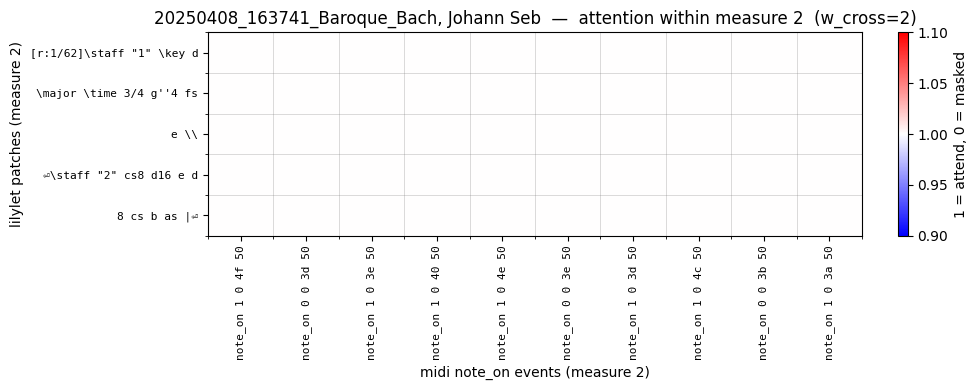

within-measure block visible fraction: 1.000 (1.0 = every note_on in this measure attends every lilylet patch in it)


In [7]:
fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(x_labels) + 4), max(4, 0.4 * len(y_labels) + 2)))
im = ax.imshow(attn_measure, cmap='bwr', aspect='auto', interpolation='nearest')

# X ticks = midi note_on events; Y ticks = lilylet patches. One tick per patch, decoded text.
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=90, fontsize=8, family='monospace')
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=8, family='monospace')
ax.set_xlabel(f'midi note_on events (measure {TARGET_MEAS})')
ax.set_ylabel(f'lilylet patches (measure {TARGET_MEAS})')
ax.set_title(f'{item["id"][:40]}  —  attention within measure {TARGET_MEAS}  (w_cross={w_cross})')

# grid lines between cells
ax.set_xticks(np.arange(-0.5, len(x_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(y_labels), 1), minor=True)
ax.grid(which='minor', color='gray', linewidth=0.4, alpha=0.5)

plt.colorbar(im, ax=ax, label='1 = attend, 0 = masked', fraction=0.03)
plt.tight_layout()
plt.show()

print(f'within-measure block visible fraction: {attn_measure.mean():.3f}',
      '(1.0 = every note_on in this measure attends every lilylet patch in it)')

## 6. (Optional) Full joint attention mask visualization

Plot the entire [T, T] mask to see all three blocks: lyl→lyl (top-left causal), midi→lyl (bottom-left windowed cross), midi→midi (bottom-right windowed causal).

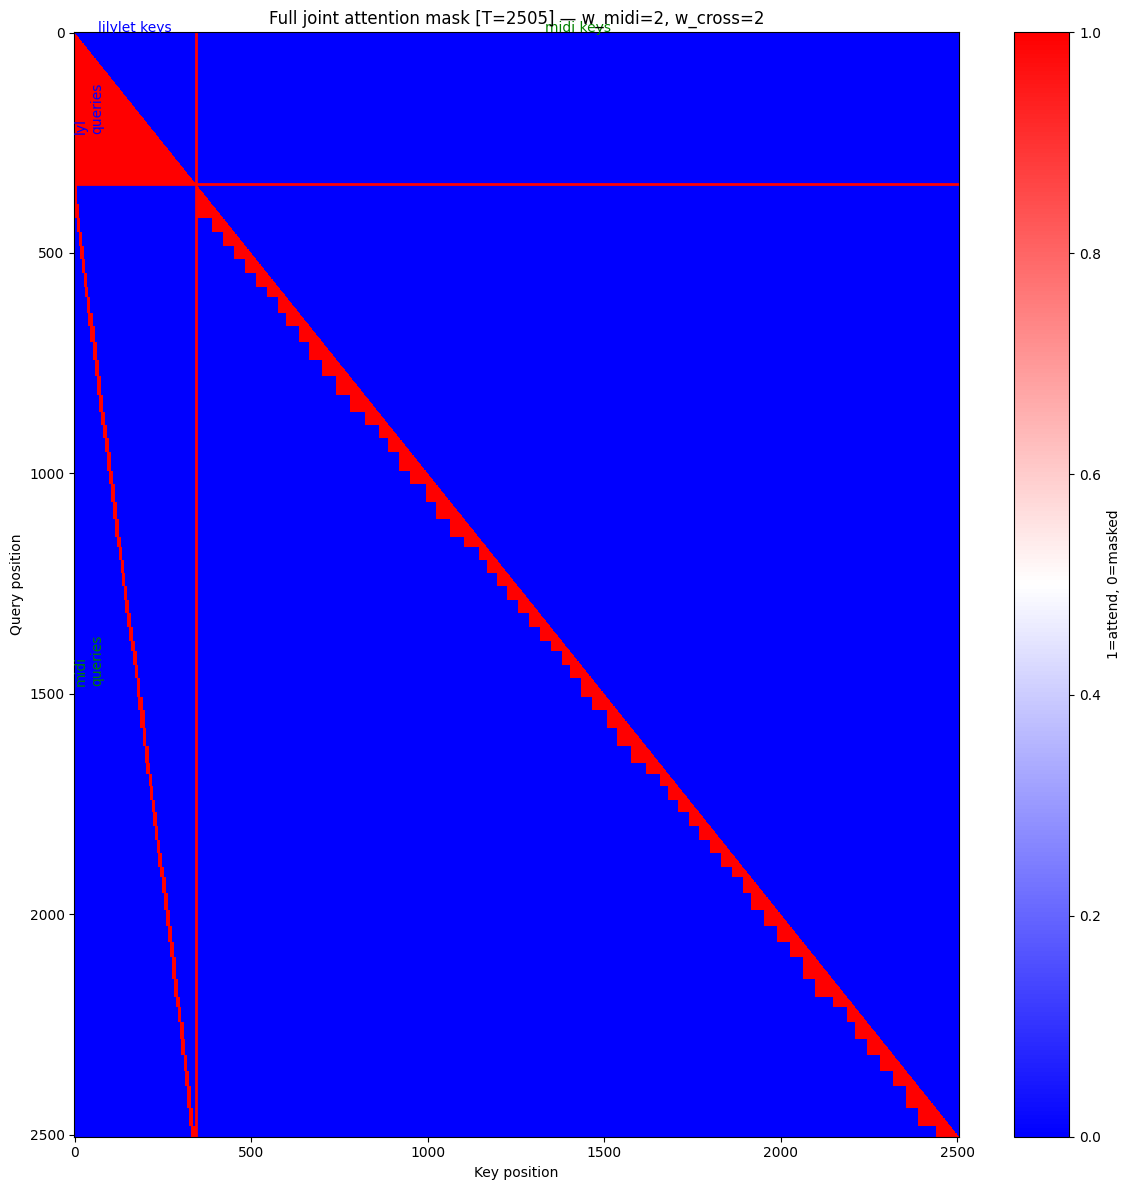

Top-left = lyl→lyl (full causal)
Bottom-left = midi→lyl (windowed cross, w_cross measures)
Bottom-right = midi→midi (windowed causal, w_midi measures)
Top-right = lyl→midi (forbidden by causal, all zero)


In [8]:
fig, ax = plt.subplots(figsize=(12, 12))
vis_np = vis.float().numpy()
im = ax.imshow(vis_np, cmap='bwr', aspect='auto', interpolation='nearest')
ax.set_xlabel('Key position')
ax.set_ylabel('Query position')
ax.set_title(f'Full joint attention mask [T={T}] — w_midi={w_midi}, w_cross={w_cross}')

# Mark the modality boundary (lyl | midi)
ax.axhline(lyl_count - 0.5, color='red', linewidth=2, label='modality boundary')
ax.axvline(lyl_count - 0.5, color='red', linewidth=2)
ax.text(lyl_count / 2, -2, 'lilylet keys', ha='center', fontsize=10, color='blue')
ax.text((lyl_count + T) / 2, -2, 'midi keys', ha='center', fontsize=10, color='green')
ax.text(-2, lyl_count / 2, 'lyl\nqueries', va='center', fontsize=10, color='blue', rotation=90)
ax.text(-2, (lyl_count + T) / 2, 'midi\nqueries', va='center', fontsize=10, color='green', rotation=90)

plt.colorbar(im, ax=ax, label='1=attend, 0=masked')
plt.tight_layout()
plt.show()

print('Top-left = lyl→lyl (full causal)')
print('Bottom-left = midi→lyl (windowed cross, w_cross measures)')
print('Bottom-right = midi→midi (windowed causal, w_midi measures)')
print('Top-right = lyl→midi (forbidden by causal, all zero)')

## 7. REAL QK attention — last layer of the midi patch-level decoder

Everything above is the boolean *mask* (allowed / masked). This section loads a **trained**
`MidiBgptTransSelfAttn` checkpoint and runs a real forward pass to read the **post-softmax
attention weights** of the LAST layer of the joint patch-level self-attention decoder
(`model.decoder`, an HF `LlamaModel`) — i.e. `softmax(QKᵀ/√d + mask)` per head.

- HF's default SDPA kernel does not expose weights, so we switch the decoder to the `eager`
  attention implementation and capture the last layer's `attn_weights` with a forward hook.
- The float mask is the bool `vis` converted to additive form (`True→0`, `False→-inf`), so
  masked keys get exactly 0 probability — the nonzero values are the learned distribution
  over the *visible* keys, which is what varies (unlike the all-1 mask block).

In [9]:
# --- load a TRAINED checkpoint (best free-running model to date: the w8 run) ---
from starry.utils.model_factory import loadModel

RUN = os.path.expanduser('~/data/models/deep-starry-logs/midi/'
                         '20260705-midi-measurewise-trans-selfattn-nota0703-w8')
run_config = Configuration.createOrLoad(RUN, volatile=True)
run_config['model.args.lyl_encoder_weights'] = None   # encoder tensors come from THIS ckpt
model = loadModel(run_config['model'], imports=run_config['imports'])
blob = torch.load(os.path.join(RUN, 'best.chkpt'), map_location='cpu', weights_only=False)
missing, unexpected = model.load_state_dict(blob['model'], strict=False)
model = model.float().eval()
# eager attention so the last decoder layer returns its post-softmax weights.
model.decoder.config._attn_implementation = 'eager'

# the trained model's OWN attention window (w8 config) governs the visibility used in training.
W = int(run_config['data.args']['w_midi'])
W_CROSS = int(run_config['data.args']['w_cross'])
print('run:', os.path.basename(RUN))
print(f'loaded (missing {len(missing)}, unexpected {len(unexpected)}) | '
      f'n_head={run_config["model.args"]["n_head"]} '
      f'n_dec_layer={run_config["model.args"]["n_dec_layer"]} | w_midi=w_cross={W}')

run: 20260705-midi-measurewise-trans-selfattn-nota0703-w8
loaded (missing 0, unexpected 0) | n_head=16 n_dec_layer=10 | w_midi=w_cross=8


In [10]:
# --- forward pass, capturing the LAST decoder layer's attention weights via a hook ---
vis_W = build_vis(modality, own_meas, src_meas, W, W_CROSS)      # visibility at the trained window

cap = {}
def _hook(m, inp, out):
    # HF LlamaAttention returns (attn_output, attn_weights[, ...]); weights = [B, n_head, T, T].
    cap['attn'] = out[1].detach() if isinstance(out, tuple) and len(out) > 1 and out[1] is not None else None
handle = model.decoder.layers[-1].self_attn.register_forward_hook(_hook)

with torch.no_grad():
    P = patches.unsqueeze(0)
    pos = torch.zeros(1, T, dtype=torch.long)
    pos[0, :lyl_count] = torch.arange(lyl_count)
    pos[0, lyl_count:] = torch.arange(T - lyl_count)             # per-modality RoPE frames
    real = torch.ones(1, lyl_count, dtype=torch.long)
    mem = model.enc_proj(model.lyl_encoder(P[:, :lyl_count], real,
                                           position_ids=pos[:, :lyl_count])['last_hidden_state'])
    emb = model._midi_embed(P)
    emb[:, :lyl_count] = mem.to(emb.dtype)                       # projected lyl prefix
    # bool mask -> additive float mask (True=attend->0, False=masked->-inf)
    fmask = torch.zeros(1, 1, T, T)
    fmask.masked_fill_(~vis_W.unsqueeze(0).unsqueeze(0), float('-inf'))
    model.decoder(inputs_embeds=emb, attention_mask=fmask, position_ids=pos, output_attentions=True)
handle.remove()

attn_last = cap['attn'][0]      # [n_head, T, T] post-softmax weights of the last layer
n_head = attn_last.shape[0]
print('last-layer attn:', tuple(attn_last.shape),
      '| row-sum mean:', round(attn_last.sum(-1).mean().item(), 4))

last-layer attn: (16, 2505, 2505) | row-sum mean: 1.0


attn_qk shape (lyl_keys x midi_queries): (5, 10)
value range: 0.0050 .. 0.0163


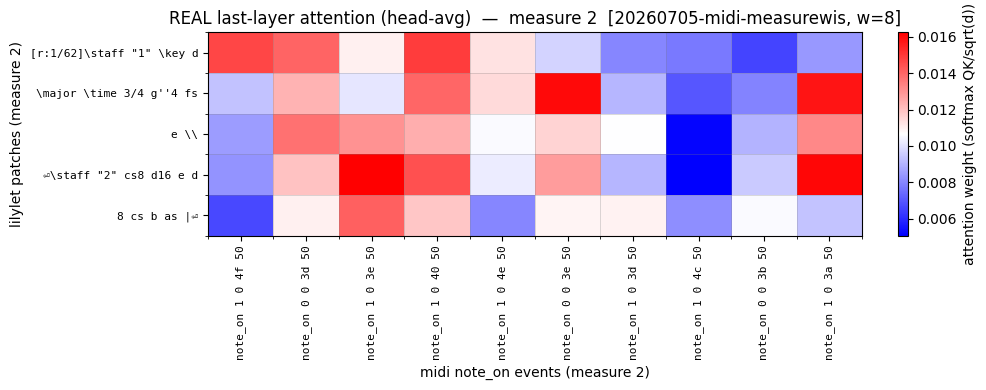

per-query attention on this measure lyl patches (fraction of total):
  note_on 1 0 4f 50      0.047
  note_on 0 0 3d 50      0.063
  note_on 1 0 3e 50      0.065
  note_on 1 0 40 50      0.068
  note_on 1 0 4e 50      0.052
  note_on 0 0 3e 50      0.061
  note_on 1 0 3d 50      0.048
  note_on 1 0 4c 50      0.033
  note_on 0 0 3b 50      0.044
  note_on 1 0 3a 50      0.063


In [11]:
# Real attention for the SAME single measure: note_on queries (X) -> lilylet keys (Y).
# attn_last[h, q, k] = prob that query q attends key k in head h. Average over heads.
attn_qk = attn_last[:, q_idx][:, :, k_idx].mean(0).T.numpy()    # [num_lyl_keys, num_midi_queries]
print('attn_qk shape (lyl_keys x midi_queries):', attn_qk.shape)
print('value range: %.4f .. %.4f' % (attn_qk.min(), attn_qk.max()))

fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(x_labels) + 4), max(4, 0.4 * len(y_labels) + 2)))
im = ax.imshow(attn_qk, cmap='bwr', aspect='auto', interpolation='nearest')

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=90, fontsize=8, family='monospace')
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=8, family='monospace')
ax.set_xlabel(f'midi note_on events (measure {TARGET_MEAS})')
ax.set_ylabel(f'lilylet patches (measure {TARGET_MEAS})')
ax.set_title(f'REAL last-layer attention (head-avg)  —  measure {TARGET_MEAS}  '
             f'[{os.path.basename(RUN)[:24]}, w={W}]')

ax.set_xticks(np.arange(-0.5, len(x_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(y_labels), 1), minor=True)
ax.grid(which='minor', color='gray', linewidth=0.4, alpha=0.5)

plt.colorbar(im, ax=ax, label='attention weight (softmax QK/sqrt(d))', fraction=0.03)
plt.tight_layout()
plt.show()

# Each column (a note_on query) sums to <=1 over ALL its visible keys across the whole sequence;
# here we show only same-measure lilylet keys, so the column sum is the FRACTION of that query's
# attention landing on this measure's lyl patches (rest -> other lyl measures + midi history + prefix).
print('per-query attention on this measure lyl patches (fraction of total):')
for j, lab in enumerate(x_labels):
    print('  %-22s %.3f' % (lab, attn_qk[:, j].sum()))

## 8. First-layer attention & per-layer max

Capture ALL decoder layers' attention in one forward pass (hook every
`model.decoder.layers[i].self_attn`), then:
- plot the FIRST layer's head-averaged attention for the same measure (layer 0 often
  attends more locally / positionally than the semantic last layer), and
- plot the per-cell MAX over all layers (head-averaged) — the strongest coupling any
  layer assigns to each (note_on query, lilylet key) pair.

In [12]:
# --- capture EVERY decoder layer's attention in one forward pass ---
caps = {}
def _mk_hook(li):
    def _h(m, inp, out):
        caps[li] = out[1].detach() if isinstance(out, tuple) and len(out) > 1 and out[1] is not None else None
    return _h
handles = [layer.self_attn.register_forward_hook(_mk_hook(i))
           for i, layer in enumerate(model.decoder.layers)]

with torch.no_grad():
    model.decoder(inputs_embeds=emb, attention_mask=fmask, position_ids=pos, output_attentions=True)
for h in handles:
    h.remove()

n_layer = len(caps)
# per layer, head-averaged submatrix for this measure: [n_layer, num_lyl_keys, num_midi_queries]
attn_layers = np.stack([
    caps[li][0][:, q_idx][:, :, k_idx].mean(0).T.numpy() for li in range(n_layer)
])
print('captured layers:', n_layer, '| per-layer submatrix:', attn_layers.shape[1:])
print('per-layer same-measure attention mass (mean over cells):',
      [round(float(attn_layers[li].mean()), 4) for li in range(n_layer)])

captured layers: 10 | per-layer submatrix: (5, 10)
per-layer same-measure attention mass (mean over cells): [0.0022, 0.1084, 0.0638, 0.0135, 0.0137, 0.0155, 0.0086, 0.0191, 0.0073, 0.0109]


layer 0 value range: 0.0005 .. 0.0079


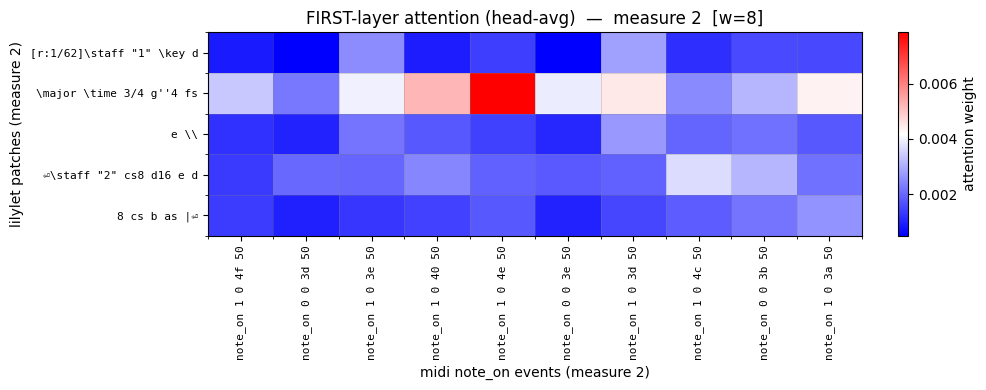

In [13]:
def plot_measure_attn(mat, title):
    '''Heatmap of a [num_lyl_keys, num_midi_queries] matrix with decoded text axes.'''
    fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(x_labels) + 4), max(4, 0.4 * len(y_labels) + 2)))
    im = ax.imshow(mat, cmap='bwr', aspect='auto', interpolation='nearest')
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=90, fontsize=8, family='monospace')
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=8, family='monospace')
    ax.set_xlabel(f'midi note_on events (measure {TARGET_MEAS})')
    ax.set_ylabel(f'lilylet patches (measure {TARGET_MEAS})')
    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, len(x_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(y_labels), 1), minor=True)
    ax.grid(which='minor', color='gray', linewidth=0.4, alpha=0.5)
    plt.colorbar(im, ax=ax, label='attention weight', fraction=0.03)
    plt.tight_layout()
    plt.show()

# FIRST layer (layer 0), head-averaged.
attn_first = attn_layers[0]
print('layer 0 value range: %.4f .. %.4f' % (attn_first.min(), attn_first.max()))
plot_measure_attn(attn_first,
    f'FIRST-layer attention (head-avg)  —  measure {TARGET_MEAS}  [w={W}]')

max-over-layers value range: 0.0115 .. 0.2973
layer that wins most cells: [ 0 41  7  0  0  0  0  1  0  1]


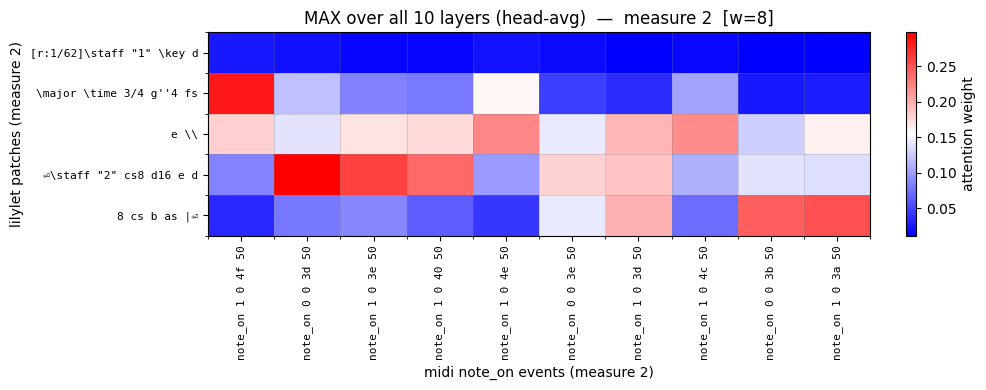

In [14]:
# MAX over all layers (per cell), head-averaged within each layer first.
attn_max = attn_layers.max(axis=0)                       # [num_lyl_keys, num_midi_queries]
argmax_layer = attn_layers.argmax(axis=0)                # which layer is strongest per cell
print('max-over-layers value range: %.4f .. %.4f' % (attn_max.min(), attn_max.max()))
print('layer that wins most cells:', np.bincount(argmax_layer.ravel(), minlength=n_layer))
plot_measure_attn(attn_max,
    f'MAX over all {n_layer} layers (head-avg)  —  measure {TARGET_MEAS}  [w={W}]')